<a href="https://colab.research.google.com/github/akshathav25/SparePart_Analysis/blob/main/SparePart_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv("/content/archive (2).zip")

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Part_ID,Part_Name,Part_Category,Brand,Truck_Model,Price,Stock_Quantity,Supplier,Warehouse_Location,Delivery_Time_Days,Warranty_Period_Months,Order_Date,Monthly_Sales,Revenue
0,P0001,Fuel Pump - Eco,Fuel System,ZF,Volvo FH,203.70,558,EuroTruck Supply,Budapest,14,6,2023-01-31,47,9573.90
1,P0002,Brake Pad Set,Brakes,Bosch,DAF XF,286.69,558,Transline Distributors,Kyiv,15,24,2023-01-07,388,111235.72
2,P0003,Torsion Bar,Suspension,Hella,Volvo FH,335.73,104,EuroTruck Supply,Rotterdam,4,24,2023-12-19,309,103740.57
3,P0004,Glow Plug - Standard,Electrical,Michelin,MAN TGX,959.13,565,CentralFleet Co,Budapest,12,12,2024-12-22,35,33569.55
4,P0005,Cylinder Head Gasket,Engine,Brembo,Renault T,898.26,284,Continental Supply,Brno,6,24,2023-12-30,107,96113.82


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Part_ID                 220 non-null    object        
 1   Part_Name               220 non-null    object        
 2   Part_Category           220 non-null    object        
 3   Brand                   220 non-null    object        
 4   Truck_Model             220 non-null    object        
 5   Price                   220 non-null    float64       
 6   Stock_Quantity          220 non-null    int64         
 7   Supplier                220 non-null    object        
 8   Warehouse_Location      220 non-null    object        
 9   Delivery_Time_Days      220 non-null    int64         
 10  Warranty_Period_Months  220 non-null    int64         
 11  Order_Date              220 non-null    datetime64[ns]
 12  Monthly_Sales           220 non-null    int64     

In [6]:
df = df.sort_values(by='Order_Date')

In [7]:
df.head()

,Part_ID,Part_Name,Part_Category,Brand,Truck_Model,Price,Stock_Quantity,Supplier,Warehouse_Location,Delivery_Time_Days,Warranty_Period_Months,Order_Date,Monthly_Sales,Revenue
1,P0002,Brake Pad Set,Brakes,Bosch,DAF XF,286.69,558,Transline Distributors,Kyiv,15,24,2023-01-07,388,111235.72
193,P0194,Torsion Bar,Suspension,MANN,DAF XF,1188.68,60,NordicAuto GmbH,Hamburg,3,6,2023-01-07,211,250811.48
214,P0215,Brake Drum,Brakes,MANN,Iveco Stralis,739.09,576,Transline Distributors,Brno,14,6,2023-01-11,50,36954.50
87,P0088,Shift Fork,Transmission,ZF,Renault T,1994.79,406,NordicAuto GmbH,Brno,3,36,2023-01-15,135,269296.65
121,P0122,Output Shaft Seal,Transmission,Scania,Renault T,854.77,130,NordicAuto GmbH,Warsaw,14,24,2023-01-19,185,158132.45


In [8]:
monthly_sales = df.groupby('Order_Date')['Monthly_Sales'].sum()

monthly_sales.head()

,Monthly_Sales
Order_Date,
2023-01-07,599
2023-01-11,50
2023-01-15,135
2023-01-19,185
2023-01-27,46


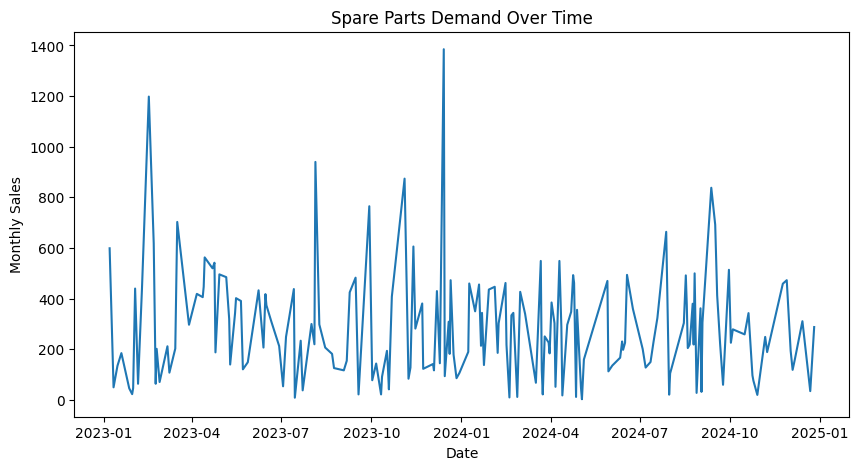

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Spare Parts Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.show()

In [10]:
df = df.reset_index(drop=True)

df['time_index'] = range(len(df))

df.head()

,Part_ID,Part_Name,Part_Category,Brand,Truck_Model,Price,Stock_Quantity,Supplier,Warehouse_Location,Delivery_Time_Days,Warranty_Period_Months,Order_Date,Monthly_Sales,Revenue,time_index
0,P0002,Brake Pad Set,Brakes,Bosch,DAF XF,286.69,558,Transline Distributors,Kyiv,15,24,2023-01-07,388,111235.72,0
1,P0194,Torsion Bar,Suspension,MANN,DAF XF,1188.68,60,NordicAuto GmbH,Hamburg,3,6,2023-01-07,211,250811.48,1
2,P0215,Brake Drum,Brakes,MANN,Iveco Stralis,739.09,576,Transline Distributors,Brno,14,6,2023-01-11,50,36954.50,2
3,P0088,Shift Fork,Transmission,ZF,Renault T,1994.79,406,NordicAuto GmbH,Brno,3,36,2023-01-15,135,269296.65,3
4,P0122,Output Shaft Seal,Transmission,Scania,Renault T,854.77,130,NordicAuto GmbH,Warsaw,14,24,2023-01-19,185,158132.45,4


In [11]:
X = df[['time_index']]
y = df['Monthly_Sales']

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [13]:
import pandas as pd

future = pd.DataFrame({
    'time_index': range(len(df), len(df) + 30)
})

forecast = model.predict(future)

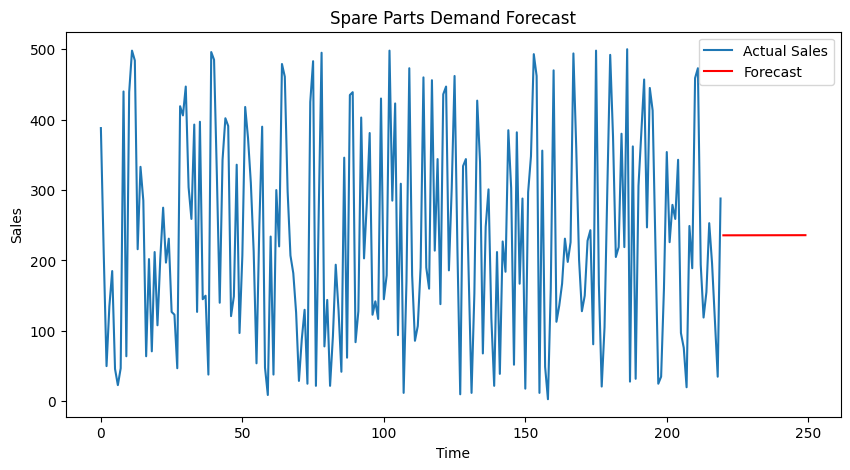

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['time_index'], y, label='Actual Sales')
plt.plot(future['time_index'], forecast, label='Forecast', color='red')

plt.title("Spare Parts Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [15]:
part_sales = df.groupby('Part_Name')['Monthly_Sales'].sum().sort_values(ascending=False)

part_sales.head()

,Monthly_Sales
Part_Name,
Accumulator,1989
Exhaust Manifold,1638
Torsion Bar,1554
Fuel Line,1220
Wiring Harness,1212


In [16]:
avg_sales = part_sales.mean()

fast_moving = part_sales[part_sales > avg_sales]
slow_moving = part_sales[part_sales <= avg_sales]

In [17]:
print("Fast Moving Parts:")
print(fast_moving.head())

print("\nSlow Moving Parts:")
print(slow_moving.head())

Fast Moving Parts:
Part_Name
Accumulator         1989
Exhaust Manifold    1638
Torsion Bar         1554
Fuel Line           1220
Wiring Harness      1212
Name: Monthly_Sales, dtype: int64

Slow Moving Parts:
Part_Name
Separator Filter              404
Exhaust Manifold - Pro        390
Exhaust Manifold - Premium    381
Coolant Hose                  363
Control Valve                 360
Name: Monthly_Sales, dtype: int64


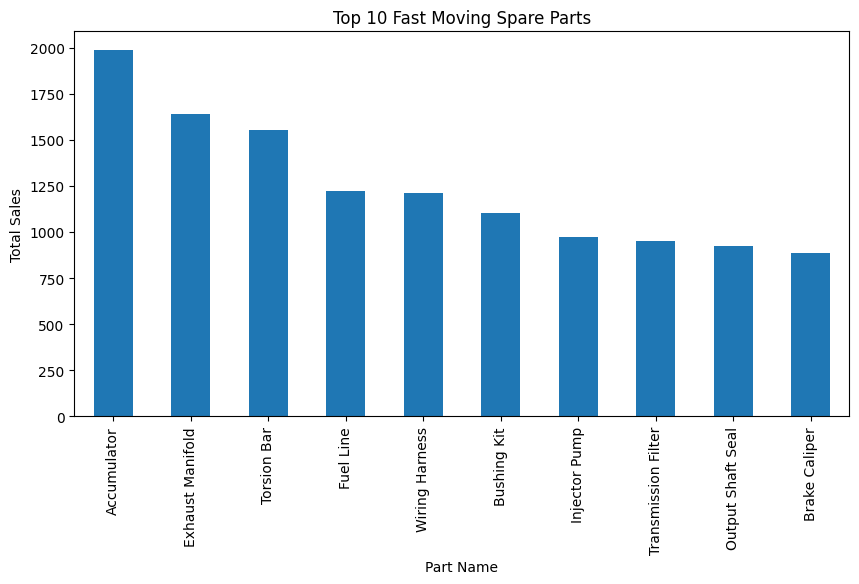

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
part_sales.head(10).plot(kind='bar')

plt.title("Top 10 Fast Moving Spare Parts")
plt.xlabel("Part Name")
plt.ylabel("Total Sales")

plt.show()

In [19]:
df.to_csv("clean_spare_parts_data.csv", index=False)

In [20]:
part_sales = df.groupby('Part_Name')['Monthly_Sales'].sum().sort_values(ascending=False)

part_sales.head(10)

,Monthly_Sales
Part_Name,
Accumulator,1989
Exhaust Manifold,1638
Torsion Bar,1554
Fuel Line,1220
Wiring Harness,1212
Bushing Kit,1105
Injector Pump,974
Transmission Filter,950
Output Shaft Seal,926


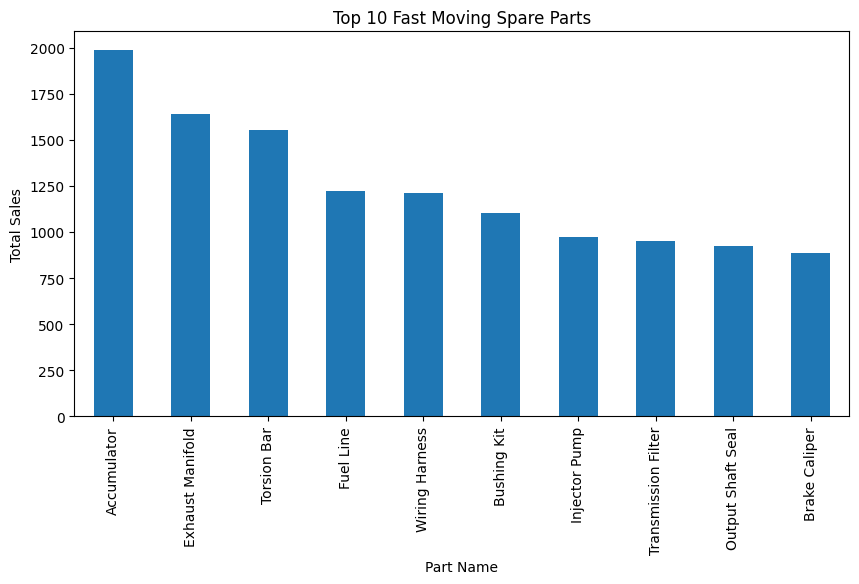

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
part_sales.head(10).plot(kind='bar')

plt.title("Top 10 Fast Moving Spare Parts")
plt.xlabel("Part Name")
plt.ylabel("Total Sales")

plt.show()

In [24]:
df.to_csv("spare_parts_data.csv", index=False)

In [26]:
from google.colab import files
files.download("spare_parts_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>